In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from matplotlib.lines import Line2D

kb = 8.617333e-2  # meV/K



# ── thermodynamic helpers ─────────────────────────────────────
def _get_energies(data, data_tm, phi):
    """Get all energies (both valleys) for a given phi."""
    phi_arr = data[:, 0]
    idx = np.argmin(np.abs(phi_arr - phi))
    e1 = data[idx, 1:];    e1 = e1[~np.isnan(e1)]
    e2 = data_tm[idx, 1:]; e2 = e2[~np.isnan(e2)]
    return np.concatenate([e1, e2])  # 8 total energies

def free_energy(data, data_tm, phi, T):
    """
    Free energy: F = -kbT * sum_n ln(1 + exp(-E_n/kbT))
    Using cosh form for numerical stability: ln(2 + 2*cosh(E/kbT))
    """
    kbT = kb * T
    e = _get_energies(data, data_tm, phi)
    # More stable form: ln(2+2*cosh(x)) = ln(2) + ln(1+cosh(x))
    return -kbT * np.sum(np.log(1 + np.exp(-e / kbT)))

def fermi(e, T):
    """Fermi-Dirac occupation number."""
    if T < 1e-12:  # Effectively zero temperature
        return 1.0 if e < 0 else 0.0
    return 1.0 / (1.0 + np.exp(e / (kb * T)))

def entropy(data, data_tm, phi, T):
    """
    Entropy directly from occupation numbers:
    S = -kb * sum_n [f_n ln f_n + (1-f_n) ln(1-f_n)]
    """
    energies = _get_energies(data, data_tm, phi)

    S_val = 0.0
    for e in energies:
        f = fermi(e, T)
        if 0 < f < 1:
            S_val += -f * np.log(f) - (1-f) * np.log(1-f)
        # f=0 or f=1 contribute 0

    return kb * S_val  # Multiply by kb for proper units

def internal_energy(data, data_tm, phi, T):
    """
    Internal energy directly from occupation numbers:
    U = sum_n f_n * E_n
    """
    energies = _get_energies(data, data_tm, phi)
    return np.sum([fermi(e, T) * e for e in energies])

def find_T_for_entropy(data, data_tm, phi, S_target, T_lo=1e-6, T_hi=100.0):
    f = lambda T: entropy(data, data_tm, phi, T) - S_target
    while f(T_hi) < 0 and T_hi < 1e5:
        T_hi *= 10.0
    if f(T_lo) * f(T_hi) > 0:
        return T_lo if abs(f(T_lo)) < abs(f(T_hi)) else T_hi
    return brentq(f, T_lo, T_hi, xtol=1e-10, rtol=1e-10)

# ── Otto cycle ────────────────────────────────────────────────
def otto(data, data_tm, phi1, phi2, Tc, Th):
    """
    Quantum Otto cycle with analytic S and U.

    Stroke A→B  adiabatic:   (phi1, Th)     → (phi2, Talpha)
    Stroke B→C  isochoric:   (phi2, Talpha) → (phi2, Tc)
    Stroke C→D  adiabatic:   (phi2, Tc)     → (phi1, Tbeta)
    Stroke D→A  isochoric:   (phi1, Tbeta)  → (phi1, Th)

    Adiabatic condition (entropic):
        S(phi1, Th) = S(phi2, Talpha)  →  solve for Talpha
        S(phi2, Tc) = S(phi1, Tbeta)   →  solve for Tbeta

    Work:   W = -ΔU  (adiabatic, no heat)
    Heat:   Q = ΔU  (isochoric, no work)

    Returns
    -------
    WAB, WCD, WT, Qhot, Qcold, Talpha, Tbeta
    """
    S_A = entropy(data, data_tm, phi1, Th)
    S_C = entropy(data, data_tm, phi2, Tc)

    Talpha = find_T_for_entropy(data, data_tm, phi2, S_A)
    Tbeta  = find_T_for_entropy(data, data_tm, phi1, S_C)

    S_B = entropy(data, data_tm, phi2, Talpha)
    S_D = entropy(data, data_tm, phi1, Tbeta)

    # verify residuals
    res_alpha = abs(S_B - S_A)
    res_beta  = abs(S_D  - S_C)
    if res_alpha > 1e-6 or res_beta > 1e-6:
        print(f"  WARNING: adiabat residuals  α={res_alpha:.2e}  β={res_beta:.2e}")


    UA = internal_energy(data, data_tm, phi1, Th)
    UB = internal_energy(data, data_tm, phi2, Talpha)
    UC = internal_energy(data, data_tm, phi2, Tc)
    UD = internal_energy(data, data_tm, phi1, Tbeta)

    WAB   = UA - UB        # adiabatic A→B
    WCD   = UC - UD        # adiabatic C→D
    Qcold = UC - UB        # isochoric B→C  (cold reservoir)
    Qhot  = UA - UD        # isochoric D→A  (hot  reservoir)
    WT    = WAB + WCD      # first law: WT = -(Qhot + Qcold)

    return WAB, WCD, WT, Qhot, Qcold, Talpha, Tbeta

# ── sweep phi2 ────────────────────────────────────────────────
def otto_sweep(data, data_tm, phi1, Tc, Th, n_phi2=600, save=False):
    """Sweep phi2 over [0, 2pi] and plot Qhot, Qcold, WT and Talpha, Tbeta."""
    phi2_arr   = np.linspace(0, 2*np.pi, n_phi2)
    WT_arr     = np.zeros(n_phi2)
    Qhot_arr   = np.zeros(n_phi2)
    Qcold_arr  = np.zeros(n_phi2)
    Talpha_arr = np.zeros(n_phi2)
    Tbeta_arr  = np.zeros(n_phi2)

    for i, phi2 in enumerate(phi2_arr):
        _, _, WT, Qhot, Qcold, Talpha, Tbeta = otto(
            data, data_tm, phi1, phi2, Tc, Th)
        WT_arr[i]     = WT
        Qhot_arr[i]   = Qhot
        Qcold_arr[i]  = Qcold
        Talpha_arr[i] = Talpha
        Tbeta_arr[i]  = Tbeta

    xticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    xlbls  = ["0", "π/2", "π", "3π/2", "2π"]

    # ── plot 1: Qhot, Qcold, WT ──────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    for ax, arr, label, color in [
        (axes[0], Qhot_arr,  r"$Q_\mathrm{hot}$  (meV)",  "crimson"),
        (axes[1], Qcold_arr, r"$Q_\mathrm{cold}$ (meV)",  "royalblue"),
        (axes[2], WT_arr,    r"$W_T$  (meV)",              "seagreen"),
    ]:
        ax.plot(phi2_arr, arr, color=color, lw=1.8)
        ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.5)
        ax.set_ylabel(label, fontsize=12)
        ax.grid(alpha=0.2)
    axes[2].set_xlabel(r"$\phi_2$", fontsize=12)
    axes[2].set_xticks(xticks); axes[2].set_xticklabels(xlbls)
    fig.suptitle(fr"Quantum Otto Cycle  —  $\phi_1$={phi1:.3f}, $T_c$={Tc} K, $T_h$={Th} K",
                 fontsize=13)
    plt.tight_layout()
    if save: plt.savefig("otto_sweep.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── plot 2: adiabatic temperatures ───────────────────────
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2.plot(phi2_arr, Talpha_arr, color="darkorange", lw=1.8, label=r"$T_\alpha$")
    ax2.plot(phi2_arr, Tbeta_arr,  color="purple",     lw=1.8, label=r"$T_\beta$")
    ax2.axhline(Th, color="crimson",   lw=0.9, ls="--", alpha=0.6, label=f"$T_h={Th}$ K")
    ax2.axhline(Tc, color="royalblue", lw=0.9, ls="--", alpha=0.6, label=f"$T_c={Tc}$ K")
    ax2.set_xlim(0, 2*np.pi)
    ax2.set_ylim(0, 0.5)
    ax2.set_xticks(xticks); ax2.set_xticklabels(xlbls)
    ax2.set_xlabel(r"$\phi_2$", fontsize=12)
    ax2.set_ylabel("Temperature (K)", fontsize=12)
    ax2.set_title(fr"Otto adiabatic temperatures  —  $\phi_1$={phi1:.3f}", fontsize=12)
    ax2.legend(fontsize=10); ax2.grid(alpha=0.2)
    plt.tight_layout()
    if save:
        plt.savefig("otto_temperatures.png", dpi=150, bbox_inches="tight")
        np.savetxt("otto_sweep.dat",
                   np.column_stack([phi2_arr, Qhot_arr, Qcold_arr, WT_arr,
                                    Talpha_arr, Tbeta_arr]),
                   header="phi2  Qhot(meV)  Qcold(meV)  WT(meV)  Talpha(K)  Tbeta(K)",
                   comments="# ")
        print("Saved otto_sweep.png, otto_temperatures.png, otto_sweep.dat")
    plt.show()

    return phi2_arr, Qhot_arr, Qcold_arr, WT_arr, Talpha_arr, Tbeta_arr

# ── heatmap ───────────────────────────────────────────────────
# ── heatmap ───────────────────────────────────────────────────
def otto_heatmap(data, data_tm, Tc, Th, n=80, save=False):
    """phi1 vs phi2 heatmap of WT with regime boundary contours."""
    phi_grid  = np.linspace(0, 2*np.pi, n)
    WT_map    = np.full((n, n), np.nan)
    Qhot_map  = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)
    regime_map = np.zeros((n, n), dtype=int)

    print("Computing Otto heatmap...")
    for i, p1 in enumerate(phi_grid):
        if i % 10 == 0:
            print(f"  row {i}/{n}")
        for j, p2 in enumerate(phi_grid):
            _, _, WT, Qhot, Qcold, _, _ = otto(data, data_tm, p1, p2, Tc, Th)
            Qhot_map[i, j]  = Qhot
            Qcold_map[i, j] = Qcold
            WT_map[i, j]    = WT*1000
            if   Qhot > 0 and Qcold < 0 and WT > 0: regime_map[i, j] = 1
            elif Qhot < 0 and Qcold > 0 and WT < 0: regime_map[i, j] = 2
            elif Qhot > 0 and Qcold < 0 and WT < 0: regime_map[i, j] = 3
            elif Qhot < 0 and Qcold < 0 and WT < 0: regime_map[i, j] = 4

    WT_masked = np.where(regime_map > 0, WT_map, np.nan)

    # Get min and max values for the colorbar (excluding NaN)
    vmin = np.nanmin(WT_masked)
    vmax = np.nanmax(WT_masked)

    # Use TwoSlopeNorm to put white at zero
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(phi_grid, phi_grid, WT_masked,
                       cmap="RdBu_r", norm=norm, shading="auto")

    # Add colorbar with appropriate ticks
    cbar = plt.colorbar(im, ax=ax, label=r"$W_T$  ($\mu$eV)")
    cbar.ax.set_ylabel(r'$W_T$  ($\mu$eV)', fontsize=30,color='blue')  # Increase label size
    cbar.ax.tick_params(labelsize=25)  # Increase tick label size

    # Set colorbar ticks to include min and max values
    from matplotlib.ticker import MaxNLocator
    # Get current ticks or create custom ones that include vmin and vmax
    cbar_ticks = [vmin, 0, vmax]
    # Add some intermediate ticks for better readability
    if vmin < 0 and vmax > 0:
        # Add one intermediate negative and positive tick
        mid_neg = vmin / 2 if vmin < 0 else None
        mid_pos = vmax / 2 if vmax > 0 else None
        if mid_neg is not None and mid_neg > vmin:
            cbar_ticks.append(mid_neg)
        if mid_pos is not None and mid_pos < vmax:
            cbar_ticks.append(mid_pos)
    cbar_ticks = sorted(set(cbar_ticks))  # Remove duplicates and sort
    cbar.set_ticks(cbar_ticks)
    # Format tick labels with appropriate precision
    cbar.ax.set_yticklabels([f'{tick:.1f}' for tick in cbar_ticks])

    # Optional: Add a white line at zero to emphasize it
    cbar.ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)



    cs_kw = dict(linewidths=2)
    ax.contour(phi_grid, phi_grid, WT_map,    levels=[0], colors="black",   **cs_kw)
    ax.contour(phi_grid, phi_grid, Qhot_map,  levels=[0], colors="crimson",
               linestyles="--", **cs_kw)
    ax.contour(phi_grid, phi_grid, Qcold_map, levels=[0], colors="purple",
               linestyles="--", **cs_kw)

    ax.legend(handles=[
        Line2D([0],[0], color='black',   lw=2, ls='-',  label=r'$W_T=0$'),
        Line2D([0],[0], color='crimson', lw=2, ls='--', label=r'$Q_\mathrm{hot}=0$'),
        Line2D([0],[0], color='purple',  lw=2, ls='--', label=r'$Q_\mathrm{cold}=0$'),
    ], fontsize=20, loc='upper center')

    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    tlbls = ["0", "π/2", "π", "3π/2", "2π"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tlbls)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tlbls)
    ax.set_xlabel(r"$\phi_2$", fontsize=40)
    ax.set_ylabel(r"$\phi_1$", fontsize=40)
    ax.tick_params(axis='both', labelsize=30)  # Increase axis tick label size
    #ax.set_title(fr"Otto $W_T(\phi_1,\phi_2)$  —  $T_c={Tc}$ K, $T_h={Th}$ K", fontsize=13)
    plt.tight_layout()

    plt.savefig("3Fig5e.png", dpi=150, bbox_inches="tight")

    plt.show()
    return phi_grid, WT_masked, regime_map




Computing AABLG $\Delta_v=0$ ...
    row 0/200


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29660/3844391202.py:33: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(e / (kb * T)))


    row 10/200
    row 20/200
    row 30/200
    row 40/200
    row 50/200
    row 60/200
    row 70/200
    row 80/200
    row 90/200
    row 100/200
    row 110/200
    row 120/200
    row 130/200
    row 140/200
    row 150/200
    row 160/200
    row 170/200
    row 180/200
    row 190/200


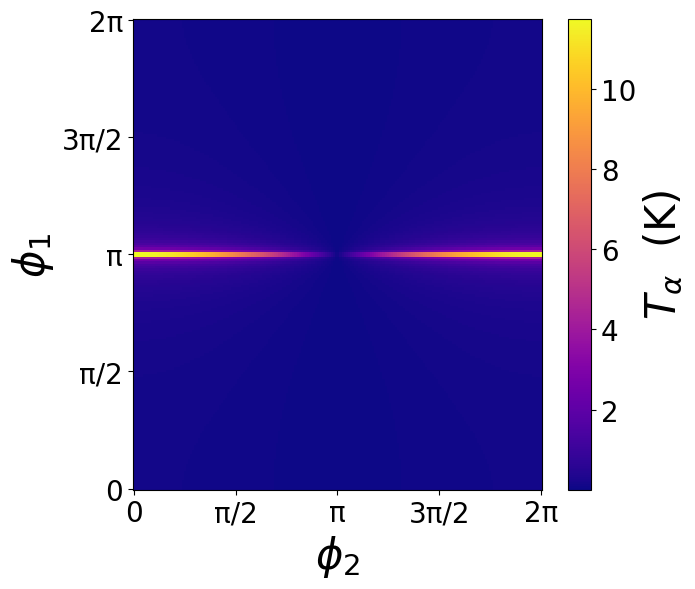

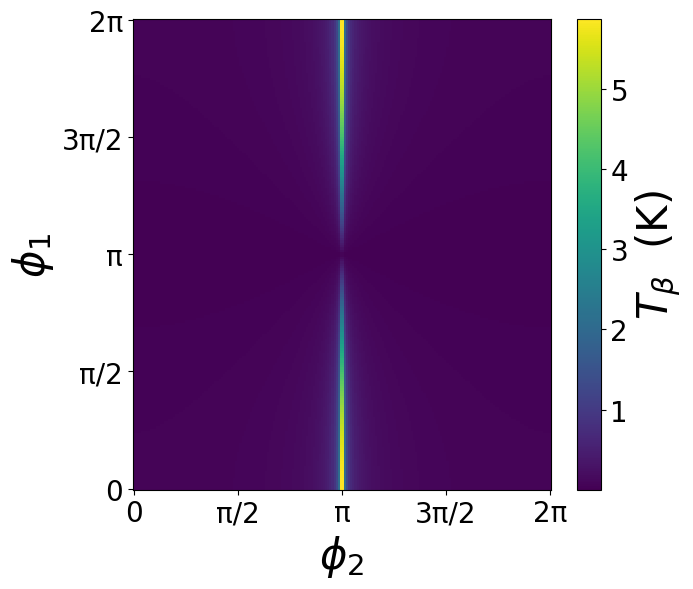


Computing AABLG $\Delta_v=0.1$ ...
    row 0/200


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29660/3844391202.py:33: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(e / (kb * T)))


    row 10/200
    row 20/200
    row 30/200
    row 40/200
    row 50/200
    row 60/200
    row 70/200
    row 80/200
    row 90/200
    row 100/200
    row 110/200
    row 120/200
    row 130/200
    row 140/200
    row 150/200
    row 160/200
    row 170/200
    row 180/200
    row 190/200


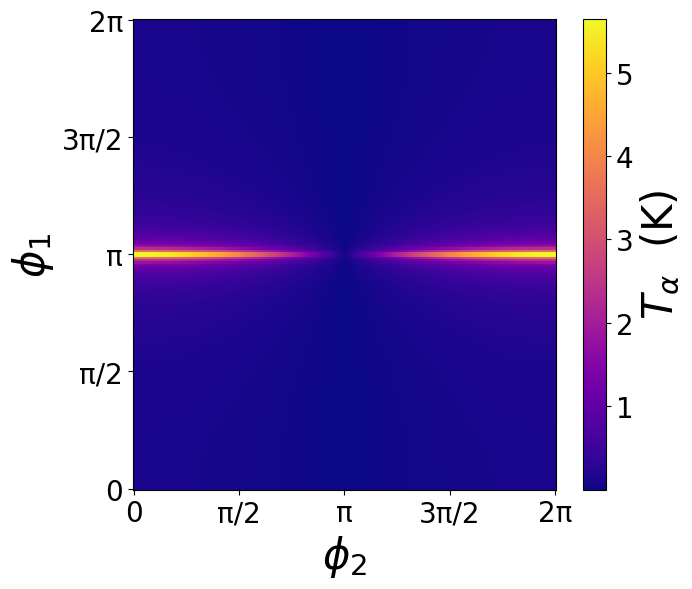

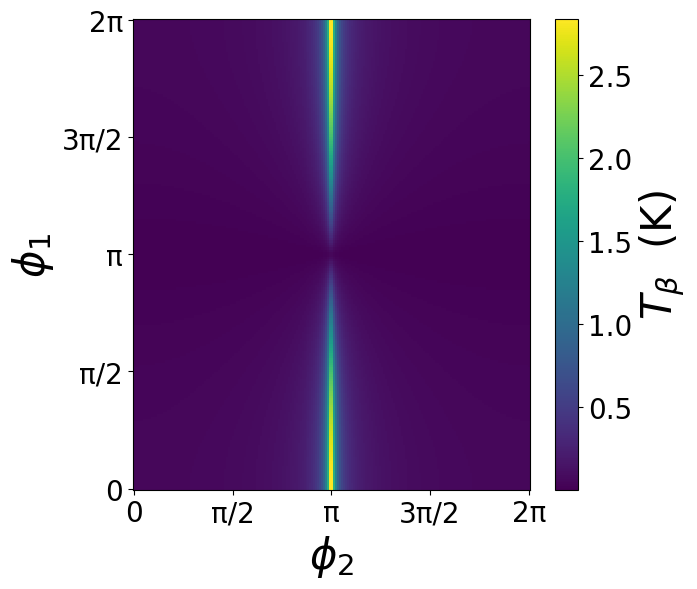


Computing MATBG $\Delta_v=0$ ...
    row 0/200


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29660/3844391202.py:33: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(e / (kb * T)))


    row 10/200
    row 20/200
    row 30/200
    row 40/200
    row 50/200
    row 60/200
    row 70/200
    row 80/200
    row 90/200
    row 100/200
    row 110/200
    row 120/200
    row 130/200
    row 140/200
    row 150/200
    row 160/200
    row 170/200
    row 180/200
    row 190/200


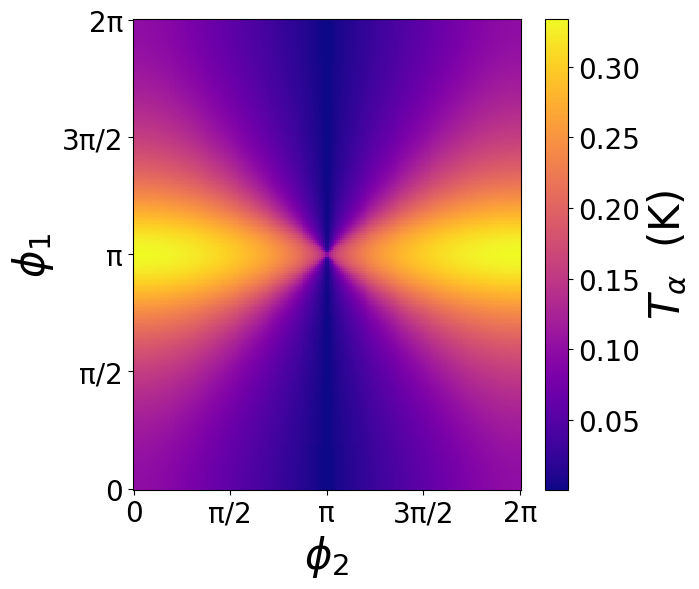

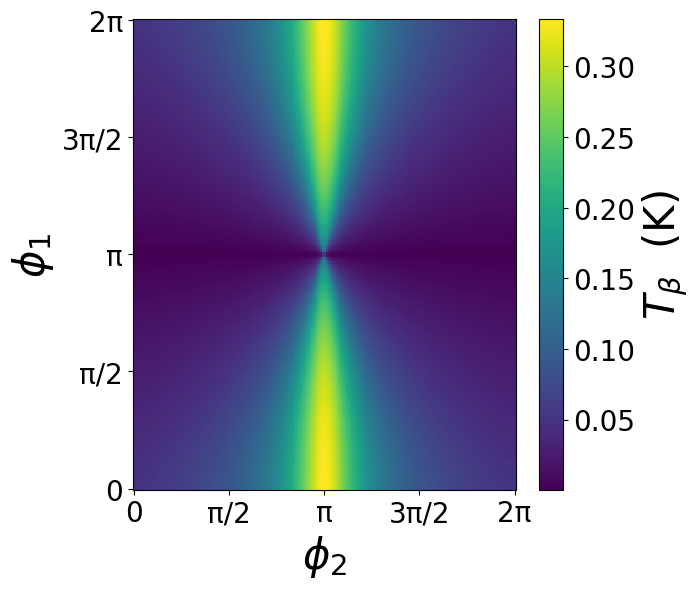


Computing MATBG $\Delta_v=0.1$ ...
    row 0/200


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29660/3844391202.py:33: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(e / (kb * T)))


    row 10/200
    row 20/200
    row 30/200
    row 40/200
    row 50/200
    row 60/200
    row 70/200
    row 80/200
    row 90/200
    row 100/200
    row 110/200
    row 120/200
    row 130/200
    row 140/200
    row 150/200
    row 160/200
    row 170/200
    row 180/200
    row 190/200


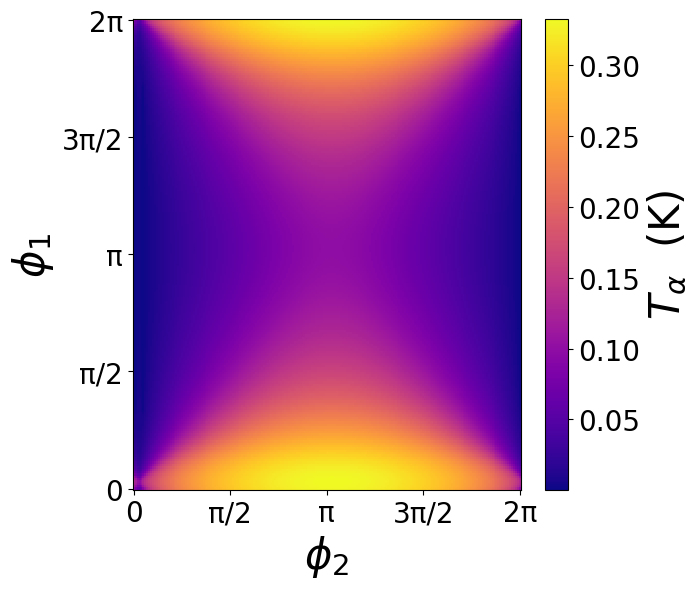

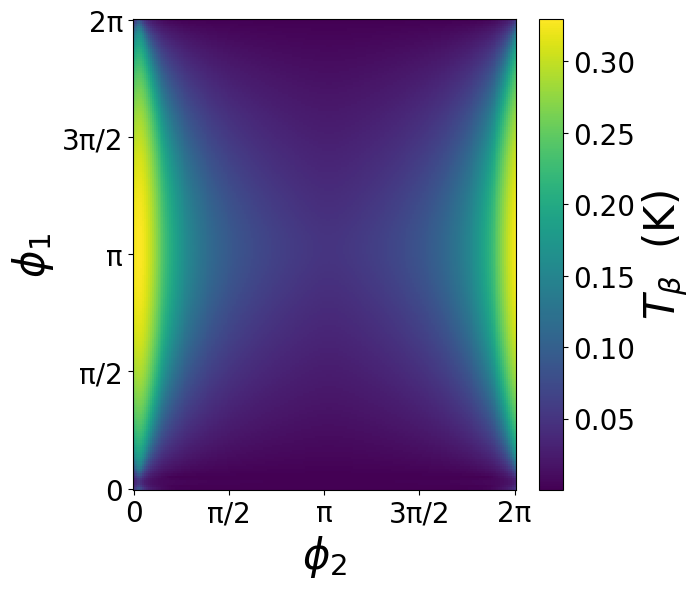

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

kb = 8.617333e-2  # meV/K



def compute_T_maps(data, data_tm, Tc, Th, n=60):
    """Compute Talpha and Tbeta over phi1 x phi2 grid."""
    phi_grid   = np.linspace(0, 2*np.pi, n)
    Talpha_map = np.full((n, n), np.nan)
    Tbeta_map  = np.full((n, n), np.nan)

    for i, p1 in enumerate(phi_grid):
        if i % 10 == 0: print(f"    row {i}/{n}")
        S_A = entropy(data, data_tm, p1, Th)   # S(phi1, Th) — only depends on p1
        for j, p2 in enumerate(phi_grid):
            S_C = entropy(data, data_tm, p2, Tc)   # S(phi2, Tc) — only depends on p2
            Talpha_map[i, j] = find_T_for_entropy(data, data_tm, p2, S_A)
            Tbeta_map[i, j]  = find_T_for_entropy(data, data_tm, p1, S_C)

    return phi_grid, Talpha_map, Tbeta_map


def plot_T_heatmaps(phi_grid, Talpha_map, Tbeta_map, label, Tc, Th, save=False):
    """Plot Talpha and Tbeta side by side for one dataset."""
    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    tlbls = ["0", "π/2", "π", "3π/2", "2π"]

    for T_map, name, cmap in [
        (Talpha_map, r"$T_\alpha$", "plasma"),
        (Tbeta_map,  r"$T_\beta$",  "viridis"),
    ]:
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.pcolormesh(phi_grid, phi_grid, T_map,
                           cmap=cmap, shading="auto")
        cbar = plt.colorbar(im, ax=ax, label=f"{name}  (K)")
        cbar.ax.tick_params(labelsize=20)  # Tick font size
        cbar.ax.set_ylabel(f"{name}  (K)", fontsize=30)  # Colorbar label size

        ax.set_xticks(ticks); ax.set_xticklabels(tlbls)
        ax.set_yticks(ticks); ax.set_yticklabels(tlbls)
        ax.set_xlabel(r"$\phi_2$", fontsize=30)
        ax.set_ylabel(r"$\phi_1$", fontsize=30)
        ax.tick_params(axis='both', labelsize=20)
        #ax.set_title(
        #    fr"{name}$(\phi_1,\phi_2)$  —  {label}"
        #    fr"  $T_c={Tc}$ K, $T_h={Th}$ K",
        #    fontsize=11)
        plt.tight_layout()
        if save:
            fname = f"T_{'alpha' if 'alpha' in name else 'beta'}_{label.replace(' ','_').replace(',','').replace('$','').replace('\\','')}.png"
            plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()


# ── parameters ───────────────────────────────────────────────
Tc = 0.05
Th = 0.10
n  = 200   # grid resolution — increase for smoother plots

datasets = [
    ("AABLG $\\Delta_v=0$",    "ABS_AABLG_taup_Dv00.dat", "ABS_AABLG_taum_Dv00.dat"),
    ("AABLG $\\Delta_v=0.1$",  "ABS_AABLG_taup_Dv01.dat", "ABS_AABLG_taum_Dv01.dat"),
    ("MATBG $\\Delta_v=0$",    "ABS_MATBG_taup_Dv00.dat", "ABS_MATBG_taum_Dv00.dat"),
    ("MATBG $\\Delta_v=0.1$",  "ABS_MATBG_taup_Dv01.dat", "ABS_MATBG_taum_Dv01.dat"),
]

# ── run ───────────────────────────────────────────────────────
for label, fp, fpm in datasets:
    print(f"\nComputing {label} ...")
    data    = np.loadtxt(fp)
    data_tm = np.loadtxt(fpm)
    phi_grid, Talpha_map, Tbeta_map = compute_T_maps(data, data_tm, Tc, Th, n=n)
    plot_T_heatmaps(phi_grid, Talpha_map, Tbeta_map, label, Tc, Th, save=False)

Computing Otto heatmap...
  row 0/250


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29660/3844391202.py:33: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(e / (kb * T)))


  row 10/250
  row 20/250
  row 30/250
  row 40/250
  row 50/250
  row 60/250
  row 70/250
  row 80/250
  row 90/250
  row 100/250
  row 110/250
  row 120/250
  row 130/250
  row 140/250
  row 150/250
  row 160/250
  row 170/250
  row 180/250
  row 190/250
  row 200/250
  row 210/250
  row 220/250
  row 230/250
  row 240/250


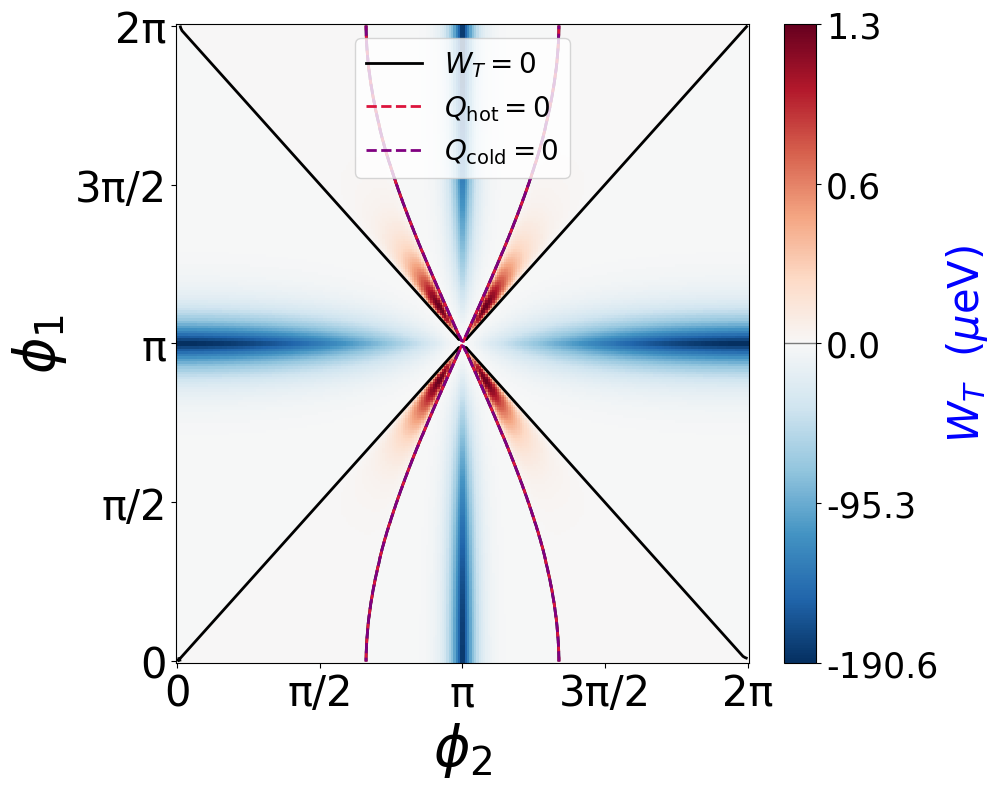

In [3]:
#data_0    = np.loadtxt("ABS_MATBG_taup_Dv00.dat")
#data_0_tm = np.loadtxt("ABS_MATBG_taum_Dv00.dat")

data_0    = np.loadtxt("ABS_AABLG_taup_Dv00.dat")
data_0_tm = np.loadtxt("ABS_AABLG_taum_Dv00.dat")

# ── run heatmap ───────────────────────────────────────────────
phi_grid, WT_out, regime_out = otto_heatmap(
    data_0, data_0_tm, Tc=0.05, Th=0.10, n=250, save=False)

In [ ]:
import matplotlib.ticker as ticker
def combined_heatmap_otto_phi(data, data_tm, Tc, Th, n=200, save=False):
    """
    Create a combined heatmap showing all three regimes with different colormaps:
    1. Heat engine: eta/eta_Carnot (plasma colormap)
    2. Refrigerator: COP/COP_Carnot (cool colormap)
    3. Cold pump: COP = |Qcold|/|WT| (hot_r colormap, capped at 50)

    Contour lines: WT=0 (white), Qhot=0 (red), Qcold=0 (blue)
    Three separate colorbars stacked vertically on the RIGHT side.
    Invalid regions (no regime) are shown in white.

    Parameters:
    -----------
    data, data_tm : phi-dependent datasets (Dv=0)
    Tc, Th : temperatures
    n : grid resolution
    save : whether to save the figure
    """
    eta_C = 1 - Tc / Th
    COP_C = Tc / (Th - Tc)
    phi_grid = np.linspace(0, 2*np.pi, n)

    # Initialize maps
    combined_map = np.full((n, n), np.nan)
    regime_map = np.zeros((n, n), dtype=int)
    WT_map = np.full((n, n), np.nan)
    Qhot_map = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)

    # Store values for each regime separately
    engine_values = np.full((n, n), np.nan)
    refrigerator_values = np.full((n, n), np.nan)
    coldpump_values = np.full((n, n), np.nan)

    print("Computing combined Otto heatmap...")
    for i, phi1 in enumerate(phi_grid):
        if i % 20 == 0:
            print(f"  row {i}/{n} (phi1 = {phi1:.3f})")
        for j, phi2 in enumerate(phi_grid):
            _, _, WT, Qhot, Qcold, _, _ = otto(data, data_tm, phi1, phi2, Tc, Th)

            WT_map[i, j] = WT
            Qhot_map[i, j] = Qhot
            Qcold_map[i, j] = Qcold

            # Heat Engine regime: Qhot > 0, Qcold < 0, WT > 0
            if Qhot > 0 and Qcold < 0 and WT > 0:
                regime_map[i, j] = 1
                engine_values[i, j] = (WT / Qhot) / eta_C
                combined_map[i, j] = engine_values[i, j]

            # Refrigerator regime: Qhot < 0, Qcold > 0, WT < 0
            elif Qhot < 0 and Qcold > 0 and WT < 0:
                regime_map[i, j] = 2
                refrigerator_values[i, j] = (abs(Qcold) / abs(WT)) / COP_C
                combined_map[i, j] = refrigerator_values[i, j]

            # Cold Pump regime: Qhot > 0, Qcold < 0, WT < 0
            elif Qhot > 0 and Qcold < 0 and WT < 0:
                regime_map[i, j] = 3
                coldpump_values[i, j] = min(abs(Qcold) / abs(WT), 50)
                combined_map[i, j] = coldpump_values[i, j]

    # Create RGB image with white for invalid regions
    rgb_image = np.ones((n, n, 3))  # Start with white (1,1,1)

    # Get colormaps
    plasma_cmap = plt.cm.plasma
    cool_cmap = plt.cm.cool
    hot_cmap = plt.cm.hot_r

    engine_mask = (regime_map == 1)
    ref_mask = (regime_map == 2)
    pump_mask = (regime_map == 3)

    # Store colorbar info
    colorbar_info = {}

    if np.any(engine_mask):
        engine_vals = engine_values[engine_mask]
        vmin_engine = 0
        vmax_engine = np.nanmax(engine_vals)
        engine_norm = plt.Normalize(vmin=vmin_engine, vmax=vmax_engine)(engine_vals)
        engine_colors = plasma_cmap(engine_norm)
        rgb_image[engine_mask] = engine_colors[:, :3]
        colorbar_info['engine'] = {
            'vmin': vmin_engine,
            'vmax': vmax_engine,
            'cmap': plasma_cmap,
            'label': r"HE: $\eta_{\mathrm{HE}}/\eta_{\mathrm{c}}$"
        }
        print(f"HE: {vmin_engine:.3f} to {vmax_engine:.3f}")

    if np.any(ref_mask):
        ref_vals = refrigerator_values[ref_mask]
        vmin_ref = 0
        vmax_ref = np.nanmax(ref_vals)
        ref_norm = plt.Normalize(vmin=vmin_ref, vmax=vmax_ref)(ref_vals)
        ref_colors = cool_cmap(ref_norm)
        rgb_image[ref_mask] = ref_colors[:, :3]
        colorbar_info['refrigerator'] = {
            'vmin': vmin_ref,
            'vmax': vmax_ref,
            'cmap': cool_cmap,
            'label': r"RE: $\mathrm{COP_{\mathrm{RE}}}/\mathrm{COP}_{\mathrm{c}}$"
        }
        print(f"Refrigerator range: {vmin_ref:.3f} to {vmax_ref:.3f}")

    if np.any(pump_mask):
        pump_vals = coldpump_values[pump_mask]
        vmin_pump = 0
        vmax_pump = 50  # Capped at 50
        pump_norm = plt.Normalize(vmin=vmin_pump, vmax=vmax_pump)(pump_vals)
        pump_colors = hot_cmap(pump_norm)
        rgb_image[pump_mask] = pump_colors[:, :3]
        colorbar_info['coldpump'] = {
            'vmin': vmin_pump,
            'vmax': vmax_pump,
            'cmap': hot_cmap,
            'label': r"CP: $\mathrm{COP_{\mathrm{CP}}} $"
        }
        print(f"Cold Pump range: {vmin_pump:.3f} to {vmax_pump:.3f}")

    # Create figure with specific size
    fig = plt.figure(figsize=(10, 8))

    # Create main plot axis (positioned on the left)
    ax = fig.add_axes([0.1, 0.1, 0.6, 0.8])  # This makes the main plot square-like

    # Create three separate axes for colorbars on the right
    cbar_width = 0.03
    cbar_spacing = 0.05
    cbar_start_x = 0.73

    # Calculate positions for three colorbars
    cbar_height = 0.24
    total_height = 3 * cbar_height + 2 * cbar_spacing
    start_y = (0.8 - total_height) / 2 + 0.05

    # Top colorbar (Heat Engine)
    cbar_ax1 = fig.add_axes([cbar_start_x, start_y + 2*(cbar_height + cbar_spacing),
                             cbar_width, cbar_height])
    # Middle colorbar (Refrigerator)
    cbar_ax2 = fig.add_axes([cbar_start_x, start_y + (cbar_height + cbar_spacing),
                             cbar_width, cbar_height])
    # Bottom colorbar (Cold Pump)
    cbar_ax3 = fig.add_axes([cbar_start_x, start_y,
                             cbar_width, cbar_height])

    # Display the RGB image in the main plot
    im = ax.imshow(rgb_image, extent=[0, 2*np.pi, 0, 2*np.pi],
                   origin='lower', aspect='equal')

    # Add contour lines
    cs_kw = dict(linewidths=2)
    ax.contour(phi_grid, phi_grid, WT_map, levels=[0],
               colors="white", linestyles="--", **cs_kw)
    ax.contour(phi_grid, phi_grid, Qhot_map, levels=[0],
               colors="red", linestyles="--", **cs_kw)
    ax.contour(phi_grid, phi_grid, Qcold_map, levels=[0],
               colors="blue", linestyles="--", **cs_kw)

    # Create colorbars in the dedicated axes
    # Create colorbars in the dedicated axes
    if 'engine' in colorbar_info:
        engine_norm = plt.Normalize(colorbar_info['engine']['vmin'],
                                    colorbar_info['engine']['vmax'])
        engine_sm = plt.cm.ScalarMappable(cmap=colorbar_info['engine']['cmap'],
                                          norm=engine_norm)
        engine_sm.set_array([])
        cbar1 = plt.colorbar(engine_sm, cax=cbar_ax1, orientation='vertical')
        cbar1.set_label(colorbar_info['engine']['label'], fontsize=20, color="blue")
        cbar1.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['engine']['vmin']
        vmax = colorbar_info['engine']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar1.set_ticks(ticks)
        # Optional: format ticks to show 1 decimal place
        cbar1.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    if 'refrigerator' in colorbar_info:
        ref_norm = plt.Normalize(colorbar_info['refrigerator']['vmin'],
                                 colorbar_info['refrigerator']['vmax'])
        ref_sm = plt.cm.ScalarMappable(cmap=colorbar_info['refrigerator']['cmap'],
                                       norm=ref_norm)
        ref_sm.set_array([])
        cbar2 = plt.colorbar(ref_sm, cax=cbar_ax2, orientation='vertical')
        cbar2.set_label(colorbar_info['refrigerator']['label'], fontsize=20, color="blue")
        cbar2.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['refrigerator']['vmin']
        vmax = colorbar_info['refrigerator']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar2.set_ticks(ticks)
        cbar2.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    if 'coldpump' in colorbar_info:
        pump_norm = plt.Normalize(colorbar_info['coldpump']['vmin'],
                                  colorbar_info['coldpump']['vmax'])
        pump_sm = plt.cm.ScalarMappable(cmap=colorbar_info['coldpump']['cmap'],
                                        norm=pump_norm)
        pump_sm.set_array([])
        cbar3 = plt.colorbar(pump_sm, cax=cbar_ax3, orientation='vertical')
        cbar3.set_label(colorbar_info['coldpump']['label'], fontsize=20, color="blue")
        cbar3.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['coldpump']['vmin']
        vmax = colorbar_info['coldpump']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar3.set_ticks(ticks)
        cbar3.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # Legend (placed inside the main plot)
    legend_elements = [
        Line2D([0], [0], color="white", lw=2, ls="--", label=r"$W_T = 0$"),
        Line2D([0], [0], color="red", lw=2, ls="--", label=r"$Q_{\mathrm{hot}} = 0$"),
        Line2D([0], [0], color="blue", lw=2, ls="--", label=r"$Q_{\mathrm{cold}} = 0$")
    ]

    ax.legend(handles=legend_elements, fontsize=20, loc="upper center")


    ax.tick_params(axis='both', labelsize=30)

    # Set ticks
    ticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    tlbls = ["0", "π/2", "π", "3π/2", "2π"]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tlbls)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tlbls)
    ax.set_xlabel(r"$\phi_2$", fontsize=40)
    ax.set_ylabel(r"$\phi_1$", fontsize=40)


    # Add title (commented out to match combined_heatmap)
    #ax.set_title(
    #    fr"Otto Combined Performance Maps — $T_c={Tc}$ K, $T_h={Th}$ K",
    #    fontsize=12, pad=20)

    # Add statistics text box (optional, commented out)
    #n_engine = np.sum(regime_map == 1)
    #n_ref = np.sum(regime_map == 2)
    #n_pump = np.sum(regime_map == 3)
    #n_invalid = n*n - n_engine - n_ref - n_pump
    #stats_text = f"Points: Engine={n_engine}, Ref={n_ref}, Pump={n_pump}, Invalid={n_invalid}"
    #ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
    #        fontsize=8, verticalalignment='bottom',
    #        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()

    plt.savefig("3Fig5f.png", dpi=150, bbox_inches="tight")


    plt.show()

    return phi_grid, combined_map, regime_map, WT_map, Qhot_map, Qcold_map, engine_values, refrigerator_values, coldpump_values


# Load data
#data = np.loadtxt("ABS_MATBG_taup_Dv00.dat")
#data_tm = np.loadtxt("ABS_MATBG_taum_Dv00.dat")

data = np.loadtxt("ABS_AABLG_taup_Dv00.dat")
data_tm = np.loadtxt("ABS_AABLG_taum_Dv00.dat")

# Parameters
Tc = 0.05
Th = 0.10

# Create heatmap
phi_grid, eta_map, regime_map, WT_map, Qhot_map, Qcold_map = combined_heatmap_otto_phi(
    data, data_tm, Tc, Th, n=500, save=False)

Computing combined Otto heatmap...
  row 0/500 (phi1 = 0.000)


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_29660/3844391202.py:33: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(e / (kb * T)))


  row 20/500 (phi1 = 0.252)
